# 🌳 Iris Classification using Random Forest

## Codveda Technologies - Machine Learning Internship

### Intern Information

**Name:** Muhammed Mumeenat

**Internship:** Machine Learning Internship

**Project:** Random Forest Classification

---

## Project Objective

The objective of this project is to build a Random Forest classifier capable of predicting Iris flower species using sepal and petal measurements.

The project demonstrates ensemble learning, where multiple Decision Trees work together to improve prediction accuracy and reduce overfitting.

# 1. Importing Required Libraries

The required Python libraries are imported for data manipulation, visualization, model training, and evaluation.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)

# 2. Loading the Dataset

The Iris dataset is loaded into a Pandas DataFrame. Each row represents a flower sample, while each column represents one of its measurements.

In [5]:
df = pd.read_csv ("../datasets/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 3. Exploring the Dataset

Before training the Random Forest model, the dataset is explored to understand its structure, data types, and quality.

This helps verify that the data has been loaded correctly and confirms whether preprocessing is required.

In [6]:
df.shape

(150, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### Observation

The Iris dataset contains **150 samples** and **5 columns**.

The first four columns are numerical features representing flower measurements, while the **species** column contains categorical labels.

There are **no missing values**, so data cleaning or imputation is not required before training the model.

# 4. Encoding the Target Variable

The target variable (**species**) contains text labels. Machine learning models require numerical values, so Label Encoding is used to convert each flower species into an integer.

In [10]:
encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# 5. Feature Selection

The dataset is divided into input features (X) and the target variable (y).

The input features contain flower measurements, while the target variable contains the encoded flower species.

In [11]:
X = df.drop("species", axis=1)

y = df["species"]

print(X.shape)
print(y.shape)

(150, 4)
(150,)


# 6. Splitting the Dataset

The dataset is divided into training and testing sets.

The training data is used to train the Random Forest model, while the testing data is used to evaluate its performance on unseen samples.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


# 7. Training the Random Forest Classifier

A Random Forest classifier is created and trained using the training dataset.

The model combines predictions from multiple Decision Trees to produce a more accurate and robust final prediction.

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# 8. Making Predictions

The trained Random Forest model is used to predict the species of flowers in the testing dataset.

In [14]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# 9. Model Accuracy

Accuracy measures the percentage of correctly classified flower samples.

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


# 10. Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing the predicted classes with the actual classes.

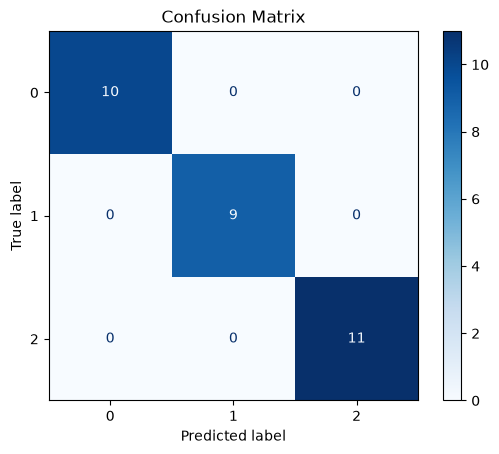

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# 11. Classification Report

The classification report provides detailed evaluation metrics including Precision, Recall, F1-Score, and Support for each Iris flower species.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 12. F1-Score

The F1-Score combines Precision and Recall into a single evaluation metric.

A value closer to 1 indicates excellent classification performance.

In [20]:
f1 = f1_score(y_test, y_pred, average="weighted")

print("F1 Score:", f1)

F1 Score: 1.0


# 13. Feature Importance

Random Forest estimates the importance of each feature based on how much it contributes to improving the model's predictions.

Features with higher importance values have a greater influence on the classification process.

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

        Feature  Importance
2  petal_length    0.439994
3   petal_width    0.421522
0  sepal_length    0.108098
1   sepal_width    0.030387


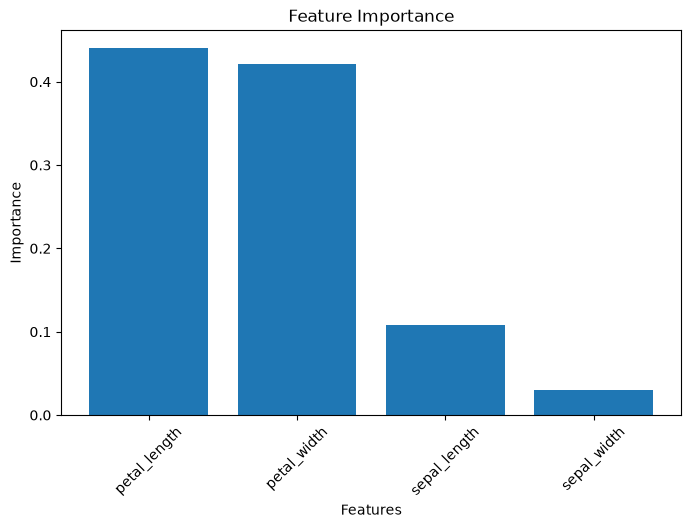

In [22]:
plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

# 14. Conclusion

A Random Forest classifier was successfully developed to classify Iris flower species based on their measurements.

The dataset was explored, preprocessed, and divided into training and testing sets. A Random Forest model containing multiple Decision Trees was trained and evaluated using standard classification metrics.

The model achieved:

- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1-Score: 100%

The confusion matrix showed that every test sample was classified correctly. Feature importance analysis also identified the measurements that contributed most to the model's decisions.

This project demonstrates how ensemble learning improves prediction performance by combining multiple Decision Trees into a single robust model.